# Analisi dati

In [27]:
import time
import influxdb_client
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
from influxdb_client.client.warnings import MissingPivotFunction

# Setup e connessione al server InfluxDB
org_name = "spamic"
token = "6ANpdrZyP8Nk7HBib5puP7dx8fJrFNG2xCPlBiXqDSKAsSfjKsUMPlgEVvoQMllyP0HCDAlherDBZZA_z42utw=="
url = "http://localhost:8086"
bucket_name = "lapd_crime_data"

client = influxdb_client.InfluxDBClient(url=url, token=token, org=org_name, timeout=600000)
query_api = client.query_api()

#  Disabilita warning inutili
warnings.simplefilter(action='ignore', category=MissingPivotFunction)

MEASUREMENT_NAME = "crime_daily"
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

In [28]:
def season_filter_clause(season=None):
    return f'|> filter(fn: (r) => r.season == "{season}")' if season else ""

def month_range(year, month):
    start = pd.Timestamp(year=year, month=month, day=1, tz="UTC")
    if month == 12:
        stop = pd.Timestamp(year=year + 1, month=1, day=1, tz="UTC")
    else:
        stop = pd.Timestamp(year=year, month=month + 1, day=1, tz="UTC")
    return start.isoformat(), stop.isoformat()

In [29]:
def run_query(flux_query):
    t0 = time.perf_counter()
    df = query_api.query_data_frame(flux_query)
    t1 = time.perf_counter()

    if isinstance(df, list):
        frames = [x for x in df if isinstance(x, pd.DataFrame) and not x.empty]
        if frames:
            df = pd.concat(frames, ignore_index=True)
        else:
            df = pd.DataFrame()

    if not df.empty and "_time" in df.columns:
        df["_time"] = pd.to_datetime(df["_time"], errors="coerce")

    return df, (t1 - t0)

In [30]:
def q1_query(season=None, start="2020-01-01T00:00:00Z", stop="2025-11-30T23:59:59Z"):
    sf = season_filter_clause(season)
    return f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start}, stop: {stop})
      |> filter(fn: (r) => r._measurement == "{MEASUREMENT_NAME}")
      |> filter(fn: (r) => r._field == "crime_count")
      {sf}
      |> keep(columns: ["_time", "_value", "area_name", "season"])
    '''

In [19]:
def q2_query(year, month, season=None):
    start, stop = month_range(year, month)
    sf = season_filter_clause(season)
    return f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start}, stop: {stop})
      |> filter(fn: (r) => r._measurement == "{MEASUREMENT_NAME}")
      |> filter(fn: (r) => r._field == "crime_count")
      {sf}
      |> group(columns: ["part", "time_band"])
      |> sum()
      |> keep(columns: ["_value", "part", "time_band"])
    '''

def q2_violent_query(year, month, season=None):
    start, stop = month_range(year, month)
    sf = season_filter_clause(season)
    return f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start}, stop: {stop})
      |> filter(fn: (r) => r._measurement == "{MEASUREMENT_NAME}")
      |> filter(fn: (r) => r._field == "violent_count")
      {sf}
      |> group(columns: ["time_band"])
      |> sum()
      |> keep(columns: ["_value", "time_band"])
    '''


In [20]:
def q3_query(season=None, start="2020-01-01T00:00:00Z", stop="2025-11-30T23:59:59Z"):
    sf = season_filter_clause(season)
    return f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start}, stop: {stop})
      |> filter(fn: (r) => r._measurement == "{MEASUREMENT_NAME}")
      |> filter(fn: (r) => r._field == "violent_count")
      {sf}
      |> group(columns: ["area_name", "_time"])
      |> sum()
      |> keep(columns: ["_time", "_value", "area_name"])
    '''


In [21]:
def q4_query(season=None, start="2020-01-01T00:00:00Z", stop="2025-11-30T23:59:59Z"):
    sf = season_filter_clause(season)
    return f'''
    from(bucket: "{bucket_name}")
      |> range(start: {start}, stop: {stop})
      |> filter(fn: (r) => r._measurement == "{MEASUREMENT_NAME}")
      |> filter(fn: (r) => r._field == "vict_age_sum" or r._field == "vict_age_count")
      {sf}
      |> group(columns: ["crime_code", "year", "_field"])
      |> sum()
      |> keep(columns: ["crime_code", "year", "_field", "_value"])
    '''

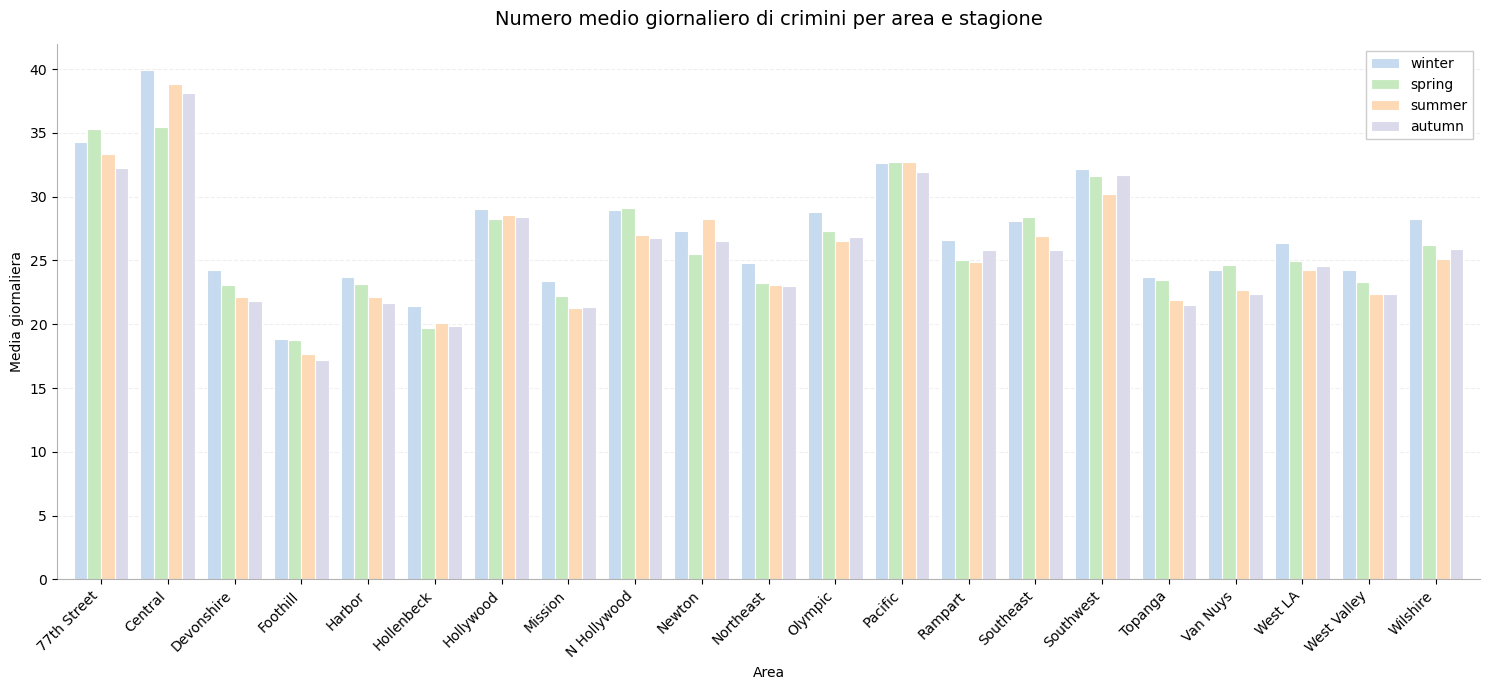

Q1 - Aree con picco stagionale


,area_name,season,avg_daily_crimes
7,Central,winter,39.931111
1,77th Street,spring,35.326087
50,Pacific,summer,32.736957
63,Southwest,winter,32.184035
33,N Hollywood,spring,29.106522
27,Hollywood,winter,29.033408
47,Olympic,winter,28.826281
57,Southeast,spring,28.434783
38,Newton,summer,28.278261
83,Wilshire,winter,28.239468


In [22]:
df1, q1_time = run_query(q1_query())

daily_area = (
    df1.groupby(["_time", "area_name", "season"], as_index=False)["_value"]
       .sum()
)

season_avg = (
    daily_area.groupby(["area_name", "season"], as_index=False)["_value"]
    .mean()
    .rename(columns={"_value": "avg_daily_crimes"})
)

pivot_q1 = season_avg.pivot(index="area_name", columns="season", values="avg_daily_crimes").fillna(0)

season_order = ["winter", "spring", "summer", "autumn"]
season_order = [s for s in season_order if s in pivot_q1.columns]
pivot_q1 = pivot_q1[season_order]

colors = {
    "winter": "#c6dbef",
    "spring": "#c7e9c0",
    "summer": "#fdd9b5",
    "autumn": "#dadaeb"
}

ax = pivot_q1.plot(
    kind="bar",
    figsize=(15, 7),
    color=[colors[s] for s in pivot_q1.columns],
    edgecolor="white",
    linewidth=0.8,
    width=0.82
)

ax.set_title("Numero medio giornaliero di crimini per area e stagione", fontsize=14, pad=14)
ax.set_ylabel("Media giornaliera")
ax.set_xlabel("Area")
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", alpha=0.20)
ax.xaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.3)
ax.spines["bottom"].set_alpha(0.3)

plt.xticks(rotation=45, ha="right")

ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=1,
    fancybox=False,
    ncol=1
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q1_avg_daily_crimes_by_area_season.png", dpi=150, bbox_inches="tight")
plt.show()

peak_season = season_avg.loc[
    season_avg.groupby("area_name")["avg_daily_crimes"].idxmax()
].sort_values("avg_daily_crimes", ascending=False)

print("Q1 - Aree con picco stagionale")
display(peak_season[["area_name", "season", "avg_daily_crimes"]].head(20))


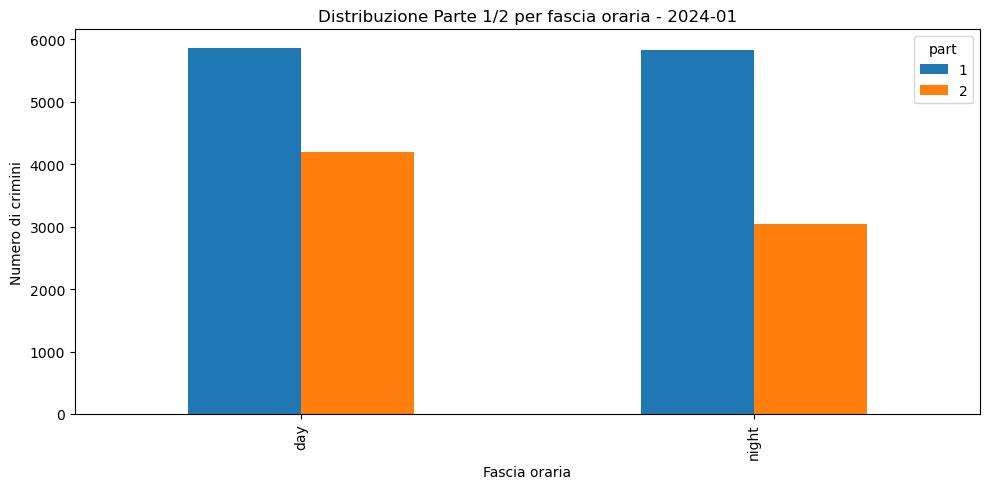

Q2 - Distribuzione crimini violenti per fascia oraria


,result,table,violent_count,time_band
0,_result,1,2361,night
1,_result,0,2343,day


I crimini violenti risultano maggiormente distribuiti in fascia: night


,time_band,1,2,total_crimes,violent_count,violent_pct
0,day,5865,4191,10056,2343,23.299523
1,night,5834,3036,8870,2361,26.617813


In [31]:
selected_year = 2024
selected_month = 1

df2, q2_time = run_query(q2_query(selected_year, selected_month))
df2v, q2v_time = run_query(q2_violent_query(selected_year, selected_month))

pivot_q2 = df2.pivot(index="time_band", columns="part", values="_value").fillna(0)
pivot_q2.plot(kind="bar", figsize=(10, 5))
plt.title(f"Distribuzione Parte 1/2 per fascia oraria - {selected_year}-{selected_month:02d}")
plt.ylabel("Numero di crimini")
plt.xlabel("Fascia oraria")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "q2_part_time_band.png", dpi=150)
plt.show()

df2v = (
    df2v.rename(columns={"_value": "violent_count"})
        .sort_values("violent_count", ascending=False)
        .reset_index(drop=True)
)

print("Q2 - Distribuzione crimini violenti per fascia oraria")
display(df2v)

if not df2v.empty:
    top_band = df2v.iloc[0]["time_band"]
    print(f"I crimini violenti risultano maggiormente distribuiti in fascia: {top_band}")

q2_compare = df2.pivot(index="time_band", columns="part", values="_value").fillna(0)
q2_compare["total_crimes"] = q2_compare.sum(axis=1)

violent_by_band = df2v.rename(columns={"_value": "violent_count"}).set_index("time_band")

q2_compare = q2_compare.join(violent_by_band[["violent_count"]], how="left").fillna(0)
q2_compare["violent_pct"] = (q2_compare["violent_count"] / q2_compare["total_crimes"]) * 100

display(q2_compare.reset_index())



In [24]:
df3, q3_time = run_query(q3_query())

peak_violent = df3.loc[
    df3.groupby("area_name")["_value"].idxmax()
].copy()

peak_violent = peak_violent.rename(columns={
    "_time": "date",
    "_value": "violent_crime_count"
}).sort_values("violent_crime_count", ascending=False)

peak_violent["month"] = peak_violent["date"].dt.month

print("Q3 - Giornata con più crimini violenti per area")
display(peak_violent[["area_name", "date", "violent_crime_count"]].head(20))

month_peaks = (
    peak_violent.groupby("month", as_index=False)["violent_crime_count"]
    .sum()
    .sort_values("violent_crime_count", ascending=False)
)

print("Q3 - Mesi con maggiore concentrazione dei picchi")
display(month_peaks)

Q3 - Giornata con più crimini violenti per area


,area_name,date,violent_crime_count
3170,Wilshire,2020-05-30 12:00:00+00:00,121
3130,Central,2020-05-29 12:00:00+00:00,45
5019,77th Street,2020-08-27 12:00:00+00:00,38
33236,Southeast,2024-05-01 12:00:00+00:00,31
6420,Southwest,2020-11-01 12:00:00+00:00,30
13267,Topanga,2021-09-23 12:00:00+00:00,27
2,Devonshire,2020-01-01 12:00:00+00:00,26
27439,Rampart,2023-07-30 12:00:00+00:00,25
26887,Mission,2023-07-04 12:00:00+00:00,24
16557,Newton,2022-02-27 12:00:00+00:00,24


Q3 - Mesi con maggiore concentrazione dei picchi


,month,violent_crime_count
3,5,215
0,1,105
5,8,79
6,9,66
4,7,49
8,11,30
1,2,24
7,10,23
2,3,20


In [25]:
df4, q4_time = run_query(q4_query())

wide_q4 = df4.pivot_table(
    index=["crime_code", "year"],
    columns="_field",
    values="_value",
    aggfunc="first"
).reset_index()

wide_q4["year"] = pd.to_numeric(wide_q4["year"], errors="coerce").astype("Int64")
wide_q4["vict_age_sum"] = pd.to_numeric(wide_q4["vict_age_sum"], errors="coerce")
wide_q4["vict_age_count"] = pd.to_numeric(wide_q4["vict_age_count"], errors="coerce")
wide_q4 = wide_q4[wide_q4["vict_age_count"] > 0]
wide_q4["avg_victim_age"] = wide_q4["vict_age_sum"] / wide_q4["vict_age_count"]

age_by_crime_year = (
    wide_q4[["crime_code", "year", "avg_victim_age"]]
    .sort_values(["crime_code", "year"])
    .reset_index(drop=True)
)

print("Q4 - Eta media delle vittime per categoria di crimine e anno")
display(age_by_crime_year.head(30))

Q4 - Eta media delle vittime per categoria di crimine e anno


_field,crime_code,year,avg_victim_age
0,110,2020,36.450142
1,110,2021,35.263158
2,110,2022,38.331633
3,110,2023,36.884498
4,110,2024,37.915789
5,113,2020,29.500000
6,113,2021,25.000000
7,113,2022,61.000000
8,113,2023,59.000000
9,121,2020,27.140430


In [26]:
# Benchmark globale vs stagionale
benchmark_season = "winter"
benchmarks = []

for season in [None, benchmark_season]:
    label = "global" if season is None else f"season={season}"

    _, t1 = run_query(q1_query(season=season))
    _, t2 = run_query(q2_query(selected_year, selected_month, season=season))
    _, t2v = run_query(q2_violent_query(selected_year, selected_month, season=season))
    _, t3 = run_query(q3_query(season=season))
    _, t4 = run_query(q4_query(season=season))

    benchmarks.append({"query": "q1", "scope": label, "seconds": t1})
    benchmarks.append({"query": "q2", "scope": label, "seconds": t2})
    benchmarks.append({"query": "q2_violent", "scope": label, "seconds": t2v})
    benchmarks.append({"query": "q3", "scope": label, "seconds": t3})
    benchmarks.append({"query": "q4", "scope": label, "seconds": t4})

benchmark_df = pd.DataFrame(benchmarks)
print("Benchmark query globali vs stagionali")
display(benchmark_df)

benchmark_pivot = benchmark_df.pivot(index="query", columns="scope", values="seconds")
display(benchmark_pivot)

client.close()

Benchmark query globali vs stagionali


,query,scope,seconds
0,q1,global,66.604645
1,q2,global,0.052233
2,q2_violent,global,0.052218
3,q3,global,100.210314
4,q4,global,191.830690
5,q1,season=winter,22.598992
6,q2,season=winter,0.059457
7,q2_violent,season=winter,0.058764
8,q3,season=winter,27.749694
9,q4,season=winter,46.532143


scope,global,season=winter
query,,
q1,66.604645,22.598992
q2,0.052233,0.059457
q2_violent,0.052218,0.058764
q3,100.210314,27.749694
q4,191.830690,46.532143
